# Estimated 2050 Climate Effects of Fossil Kerosene-Based Aviation

This notebook recreates the climate effects figure showing the breakdown of different emission types and their contributions.

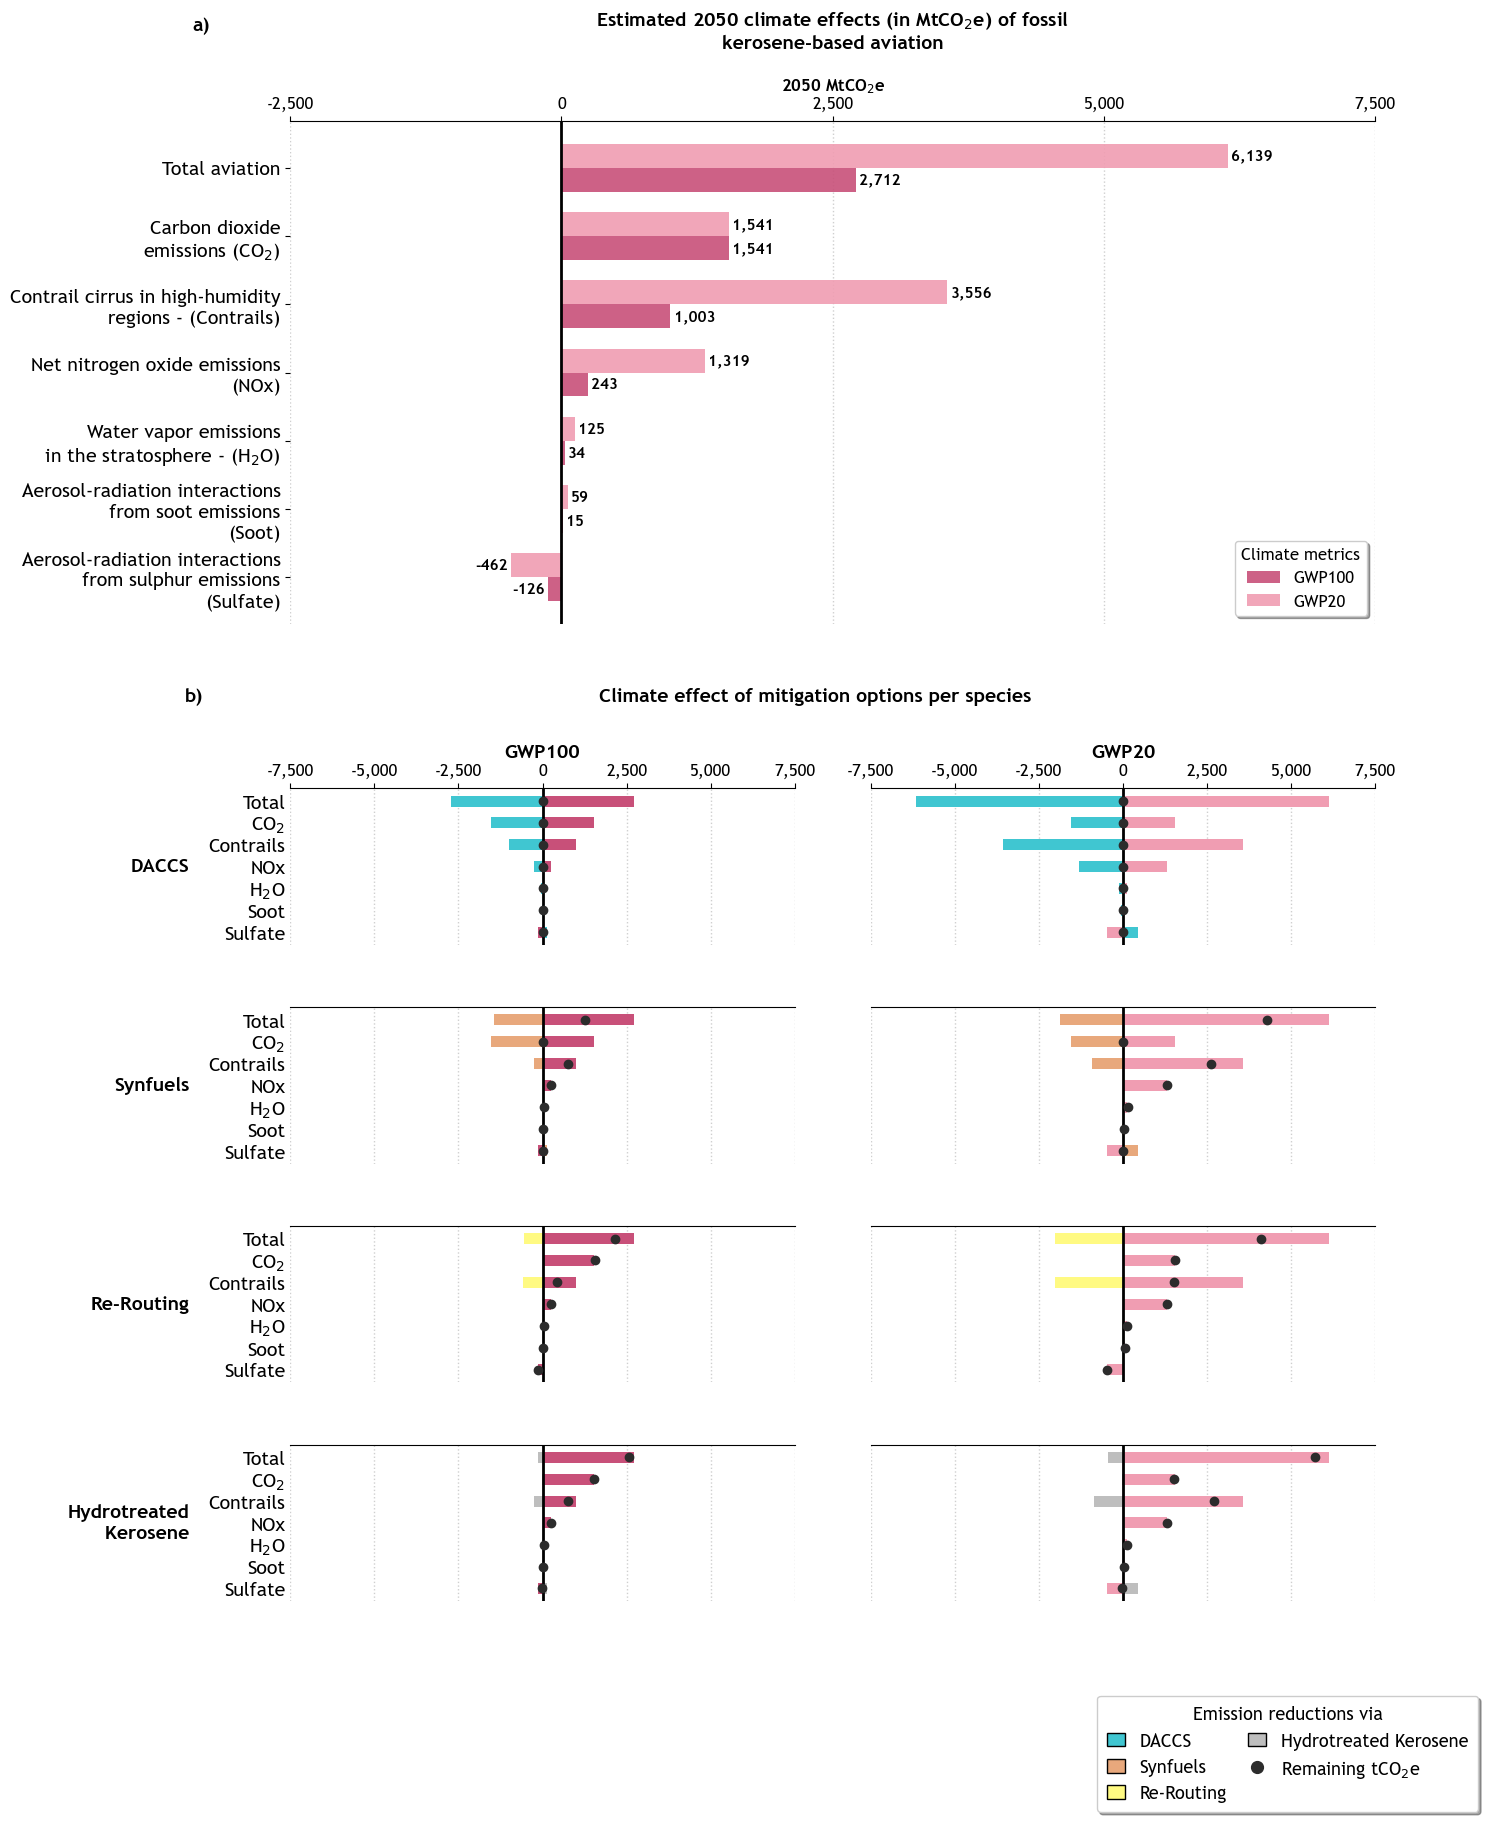

In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter
import numpy as np

# Set font to Trebuchet MS
plt.rcParams['font.family'] = 'Trebuchet MS'
markersize = 6  # Size for dark grey dots
# ============ PANEL A ============
fig = plt.figure(figsize=(14, 20))
gs = gridspec.GridSpec(2, 1, figure=fig, height_ratios=[1.3, 2.1], hspace=0.25)

# Panel A
ax_a = fig.add_subplot(gs[0])

categories = [
    'Aerosol-radiation interactions\nfrom sulphur emissions\n(Sulfate)',
    'Aerosol-radiation interactions\nfrom soot emissions\n(Soot)',
    'Water vapor emissions\n in the stratosphere - (H$_2$O)',
    'Net nitrogen oxide emissions\n(NOx)',
    'Contrail cirrus in high-humidity\n regions - (Contrails)',
    'Carbon dioxide\nemissions (CO$_2$)',
    'Total aviation'
]

gwp100_values = [-126, 15, 34, 243, 1003, 1541, 2712]
gwp20_values = [-462, 59, 125, 1319, 3556, 1541, 6139]

y_pos = np.arange(len(categories))
bar_height = 0.35

color_gwp100 = '#C85079'
color_gwp20 = '#F09DB2'

bars1 = ax_a.barh(y_pos - bar_height/2, gwp100_values, bar_height, 
                   label='GWP100', color=color_gwp100, alpha=0.9)
bars2 = ax_a.barh(y_pos + bar_height/2, gwp20_values, bar_height, 
                   label='GWP20', color=color_gwp20, alpha=0.9)

# Add value labels on bars
def add_value_labels(bars):
    for bar in bars:
        width = bar.get_width()
        if width != 0:
            label_x_pos = width + (30 if width > 0 else -30)
            ax_a.text(label_x_pos, bar.get_y() + bar.get_height()/2, 
                   f'{int(width):,}', 
                   ha='left' if width > 0 else 'right', 
                   va='center', fontsize=11, fontweight='bold')

add_value_labels(bars1)
add_value_labels(bars2)

ax_a.set_yticks(y_pos)
ax_a.set_yticklabels(categories, fontsize=14)
ax_a.xaxis.tick_top()
ax_a.xaxis.set_label_position('top')
ax_a.set_xlabel('2050 MtCO$_2$e', fontsize=12, fontweight='bold')
ax_a.text(-0.09, 1.18, 'a)', transform=ax_a.transAxes, fontsize=14, fontweight='bold')
ax_a.set_title('Estimated 2050 climate effects (in MtCO$_2$e) of fossil\nkerosene-based aviation', 
             fontsize=14, fontweight='bold', pad=20)

ax_a.set_xlim(-2500, 7500)
ax_a.set_xticks(np.arange(-2500, 8000, 2500))
ax_a.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{int(x):,}'))
ax_a.tick_params(axis='x', labelsize=12)
ax_a.axvline(x=0, color='black', linewidth=2)
ax_a.grid(axis='x', alpha=0.6, linestyle=':', linewidth=1)
ax_a.set_axisbelow(True)

# Remove spines from panel A
ax_a.spines['bottom'].set_visible(False)
ax_a.spines['left'].set_visible(False)
ax_a.spines['right'].set_visible(False)

ax_a.legend(title='Climate metrics', loc='lower right', fontsize=12, 
         title_fontsize=12, frameon=True, fancybox=True, shadow=True)

# ============ PANEL B ============
gs_b = gridspec.GridSpecFromSubplotSpec(4, 2, subplot_spec=gs[1], 
                                       hspace=0.4, wspace=0.15)

strategies = ['DACCS', 'Synfuels', 'Re-Routing', 'Hydrotreated\n Kerosene']
metrics = ['GWP100', 'GWP20']

# Baseline values for reference
gwp100_values_b = [-126, 15, 34, 243, 1003, 1541, 2712]
gwp20_values_b = [-462, 59, 125, 1319, 3556, 1541, 6139]

# Synfuels values (multiply by -1 for display)
synfuels_gwp100 = [126, -5, 4, 0, -260, -1541, -1438]
synfuels_gwp20 = [462, -18, 15,0, -924, -1541, -1860] 

rerouting_gwp100 = [0.4, 0.7, 0.1, 0.7, -571, 5,-565]
rerouting_gwp20 = [1.4, 0.18, 0.38, 4, -2026, 5, -2021] 

htk_gwp100 = [120, -5, 0, 0, -240, -15, -140]  
htk_gwp20 = [448, -21, 0, 0, -853, -15, -441] 

# Create baseline list - do not convert to positive
gwp100_pos = [x for x in gwp100_values_b]
gwp20_pos = [x for x in gwp20_values_b]
bar_height_b = 0.5

# Shortened labels matching the order of values
short_labels = ['Sulfate', 'Soot', 'H$_2$O', 'NOx', 'Contrails', 'CO$_2$', 'Total']

color_daccs = '#40C6D1'  # Teal for DACCS
color_synfuels = '#E8A87C'  # Warm brown for Synfuels
color_rerouting = '#FFFA82'
color_htk = '#BEBEBE'  # Light orange for Hydrotreated Kerosene
color_grey = "#2C2C2C"  # Dark grey for dots

for row, strategy in enumerate(strategies):
    for col, metric in enumerate(metrics):
        ax = fig.add_subplot(gs_b[row, col])
        
        # Add baseline reference bars
        if metric == 'GWP100':
            ax.barh(np.arange(len(gwp100_pos)), gwp100_pos, bar_height_b, 
                   color=color_gwp100, alpha=1)
        else:  # GWP20
            ax.barh(np.arange(len(gwp20_pos)), gwp20_pos, bar_height_b, 
                   color=color_gwp20, alpha=1)
        
        # For DACCS row, add negative bars and dots
        if strategy == 'DACCS':
            if metric == 'GWP100':
                # Add negative bars (abatement going left)
                ax.barh(np.arange(len(gwp100_pos)), [-x for x in gwp100_pos], bar_height_b, 
                       color=color_daccs, alpha=1)
                # Add dark grey dots at the end (x = 0 for complete abatement)
                for i in range(len(gwp100_pos)):
                    ax.plot(0, i, 'o', color=color_grey, markersize=markersize, zorder=5)
            else:  # GWP20
                # Add negative bars (abatement going left)
                ax.barh(np.arange(len(gwp20_pos)), [-x for x in gwp20_pos], bar_height_b, 
                       color=color_daccs, alpha=1)
                # Add dark grey dots at the end (x = 0 for complete abatement)
                for i in range(len(gwp20_pos)):
                    ax.plot(0, i, 'o', color=color_grey, markersize=markersize, zorder=5)
        
        # For Synfuels row, add bars showing change from baseline
        elif strategy == 'Synfuels':
            if metric == 'GWP100':
                ax.barh(np.arange(len(synfuels_gwp100)), synfuels_gwp100, bar_height_b, 
                       color=color_synfuels, alpha=1)
                # Add dark grey dots at baseline + synfuels (final emissions)
                for i in range(len(synfuels_gwp100)):
                    final_value = gwp100_pos[i] + synfuels_gwp100[i]
                    ax.plot(final_value, i, 'o', color=color_grey, markersize=markersize, zorder=5)
            else:  # GWP20
                if synfuels_gwp20:
                    ax.barh(np.arange(len(synfuels_gwp20)), synfuels_gwp20, bar_height_b, 
                           color=color_synfuels, alpha=1)
                    # Add dark grey dots at baseline + synfuels (final emissions)
                    for i in range(len(synfuels_gwp20)):
                        final_value = gwp20_pos[i] + synfuels_gwp20[i]
                        ax.plot(final_value, i, 'o', color=color_grey, markersize=markersize, zorder=5)

        elif strategy == "Re-Routing":
            if metric == 'GWP100':
                ax.barh(np.arange(len(rerouting_gwp100)), rerouting_gwp100, bar_height_b, 
                       color=color_rerouting, alpha=1)  # Light green
                for i in range(len(rerouting_gwp100)):
                    final_value = gwp100_pos[i] + rerouting_gwp100[i]  # Reduction from baseline
                    ax.plot(final_value, i, 'o', color=color_grey, markersize=markersize, zorder=5)
            else:  # GWP20
                ax.barh(np.arange(len(rerouting_gwp20)), rerouting_gwp20, bar_height_b, 
                       color=color_rerouting, alpha=1)  # Light green
                for i in range(len(rerouting_gwp20)):
                    final_value = gwp20_pos[i] + rerouting_gwp20[i]  # Reduction from baseline
                    ax.plot(final_value, i, 'o', color=color_grey, markersize=markersize, zorder=5)

        elif strategy == "Hydrotreated\n Kerosene":
            if metric == 'GWP100':
                ax.barh(np.arange(len(htk_gwp100)), htk_gwp100, bar_height_b, 
                       color=color_htk, alpha=1)  # Light orange
                for i in range(len(htk_gwp100)):
                    final_value = gwp100_pos[i] + htk_gwp100[i]  # Reduction from baseline
                    ax.plot(final_value, i, 'o', color=color_grey, markersize=markersize, zorder=5)
            else:  # GWP20
                ax.barh(np.arange(len(htk_gwp20)), htk_gwp20, bar_height_b, 
                       color=color_htk, alpha=1)  
                for i in range(len(htk_gwp20)):
                    final_value = gwp20_pos[i] + htk_gwp20[i]  # Reduction from baseline
                    ax.plot(final_value, i, 'o', color=color_grey, markersize=markersize, zorder=5)
                

        
        # Setup axis
        ax.set_xlim(-7500, 7500)
        ax.set_xticks(np.arange(-7500, 8000, 2500))
        ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{int(x):,}'))
        ax.axvline(x=0, color='black', linewidth=2)
        ax.grid(axis='x', alpha=0.6, linestyle=':', linewidth=1)
        ax.set_axisbelow(True)
        
        # Set y-axis labels (only on left column)
        ax.set_yticks(np.arange(len(short_labels)))
        if col == 0:
            ax.set_yticklabels(short_labels, fontsize=14)
        else:
            ax.set_yticklabels([])
        
        # Remove y-axis ticks
        ax.tick_params(axis='y', length=0)
        
        # Only show x-axis labels and ticks on top row
        if row == 0:
            ax.xaxis.tick_top()
            ax.set_xticklabels([f'{int(x):,}' for x in np.arange(-7500, 8000, 2500)], fontsize=12)
        else:
            ax.set_xticklabels([])
            ax.tick_params(axis='x', which='both', length=0)
        
        # Remove spines
        ax.spines['bottom'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        # Column headers (only on top row)
        if row == 0:
            ax.text(0.5, 1.20, metric, fontsize=14, fontweight='bold', 
                   ha='center', transform=ax.transAxes)
        
        # Row labels (only on left column)
        if col == 0:
            ax.text(-0.2, 0.5, strategy, fontsize=14, fontweight='bold', 
                   ha='right', va='center', transform=ax.transAxes)

# Add panel b label and title
fig.text(0.05, 0.59, 'b)', fontsize=14, fontweight='bold')
fig.text(0.5, 0.59, 'Climate effect of mitigation options per species', 
         fontsize=14, fontweight='bold', ha='center')

# Leave breathing room below panel b for legend
fig.subplots_adjust(bottom=0.14)

# Add legend for mitigation strategies (only for panel b)
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_elements = [
    Patch(facecolor=color_daccs, edgecolor='black', label='DACCS'),
    Patch(facecolor=color_synfuels, edgecolor='black', label='Synfuels'),
    Patch(facecolor=color_rerouting, edgecolor='black', label='Re-Routing'),
    Patch(facecolor=color_htk, edgecolor='black', label='Hydrotreated Kerosene'),
    Line2D([0], [0], marker='o', linestyle='None', markerfacecolor=color_grey, markeredgecolor=color_grey, markersize=8.5, label='Remaining tCO$_2$e')
]
fig.legend(handles=legend_elements, loc='lower right', bbox_to_anchor=(0.98, 0.03), ncol=2, fontsize=13, frameon=True, fancybox=True, shadow=True, title='Emission reductions via', title_fontsize=13, handlelength=1.0, handleheight=0.8, borderpad=0.55, labelspacing=0.45, columnspacing=1.2)

plt.savefig('../outputs/climate_effects_2050.png', dpi=300, bbox_inches='tight')
plt.show()